# Research Center Quality Classification
## Machine Learning Assignment — EDA, Clustering & Interpretation

This notebook covers all required stages:
1. **Exploratory Data Analysis (EDA)**
2. **Feature Selection**
3. **K-Means Clustering**
4. **Model Interpretation**

The trained model is exported to `cluster_model.pkl` and consumed by the `app.py` FastAPI endpoint.


## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110


## 1. Load & Inspect the Dataset

In [2]:
df = pd.read_csv("research_centers.csv")

print(f"Shape: {df.shape}")
df.head()


Shape: (50, 10)


,researchCenterId,researchCenterName,city,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
0,RC-014,Research Center 14,City 4,50.7713,-1.9260,3,1,0,0.374488,0.177506
1,RC-040,Research Center 40,City 2,50.5088,-1.3637,2,1,1,0.391903,0.108965
2,RC-031,Research Center 31,City 4,50.2202,-1.2889,3,0,1,0.293552,0.076155
3,RC-046,Research Center 46,City 5,50.9362,-1.3040,11,4,4,0.884502,0.697016
4,RC-018,Research Center 18,City 2,50.0254,-1.8921,10,4,5,0.842611,0.568983


In [3]:
print("Data types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())


Data types:
 researchCenterId               str
researchCenterName             str
city                           str
latitude                   float64
longitude                  float64
internalFacilitiesCount      int64
hospitals_10km               int64
pharmacies_10km              int64
facilityDiversity_10km     float64
facilityDensity_10km       float64
dtype: object

Missing values:
 researchCenterId           0
researchCenterName         0
city                       0
latitude                   0
longitude                  0
internalFacilitiesCount    0
hospitals_10km             0
pharmacies_10km            0
facilityDiversity_10km     0
facilityDensity_10km       0
dtype: int64


In [4]:
df.describe().round(3)


,latitude,longitude,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
count,50.000,50.000,50.000,50.00,50.000,50.000,50.000
mean,50.543,-1.555,5.660,1.86,2.240,0.569,0.321
std,0.320,0.254,3.147,1.34,1.685,0.250,0.183
min,50.007,-1.977,1.000,0.00,0.000,0.120,0.057
25%,50.240,-1.747,3.000,1.00,1.000,0.344,0.174
50%,50.635,-1.561,5.000,2.00,2.000,0.586,0.298
75%,50.831,-1.374,8.750,3.00,3.000,0.800,0.476
max,50.995,-1.049,11.000,4.00,5.000,0.993,0.697


In [5]:
# City distribution
print("Samples per city:")
print(df["city"].value_counts())


Samples per city:
city
City 3    14
City 1    11
City 4    10
City 5     9
City 2     6
Name: count, dtype: int64


## 2. Exploratory Data Analysis

### 2.1 Distribution of Internal Facilities
We start by examining how internal facility counts are spread across all centers.


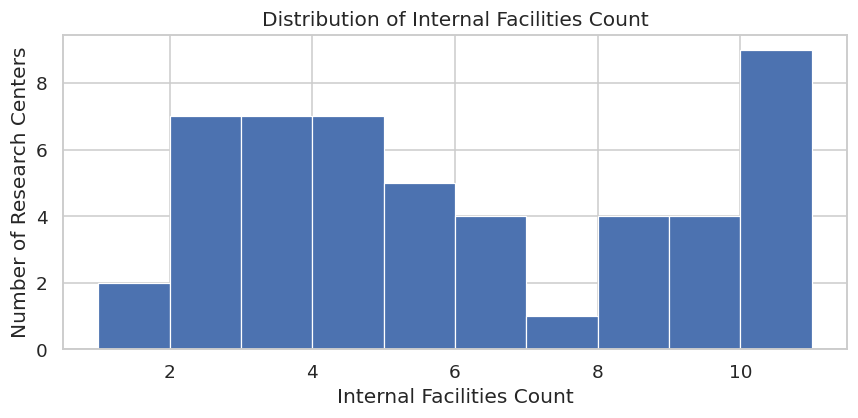


Key stats:
count    50.00
mean      5.66
std       3.15
min       1.00
25%       3.00
50%       5.00
75%       8.75
max      11.00
Name: internalFacilitiesCount, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["internalFacilitiesCount"], bins=10, color="#4C72B0", edgecolor="white", linewidth=0.8)
ax.set_xlabel("Internal Facilities Count")
ax.set_ylabel("Number of Research Centers")
ax.set_title("Distribution of Internal Facilities Count")
plt.tight_layout()
plt.savefig("fig_histogram_facilities.png", bbox_inches="tight")
plt.show()
print("\nKey stats:")
print(df["internalFacilitiesCount"].describe().round(2))


### 2.2 Hospital & Pharmacy Access by City

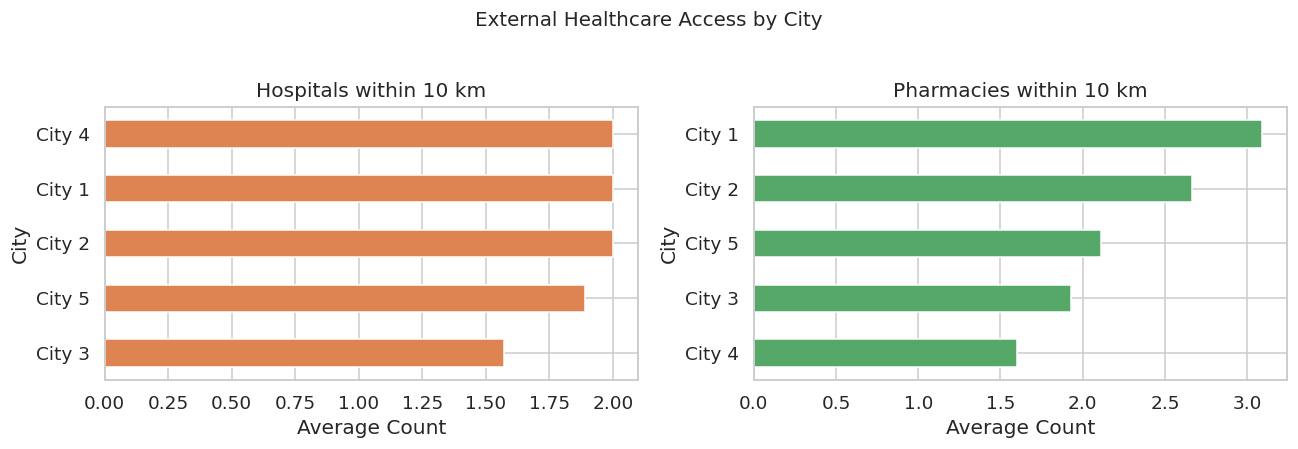

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color, label in zip(
    axes,
    ["hospitals_10km", "pharmacies_10km"],
    ["#DD8452", "#55A868"],
    ["Hospitals within 10 km", "Pharmacies within 10 km"],
):
    city_means = df.groupby("city")[col].mean().sort_values()
    city_means.plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("Average Count")
    ax.set_ylabel("City")

plt.suptitle("External Healthcare Access by City", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("fig_healthcare_by_city.png", bbox_inches="tight")
plt.show()


### 2.3 Scatter: Internal Facilities vs Hospitals & Pharmacies

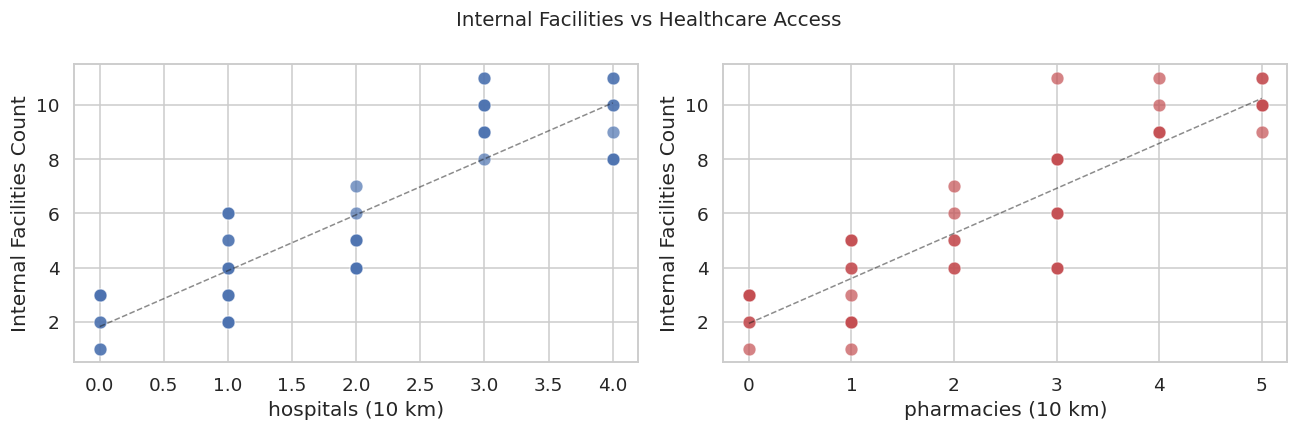

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, x_col, color in zip(
    axes,
    ["hospitals_10km", "pharmacies_10km"],
    ["#4C72B0", "#C44E52"],
):
    ax.scatter(
        df[x_col], df["internalFacilitiesCount"],
        alpha=0.7, edgecolors="white", linewidth=0.4, s=70, color=color
    )
    ax.set_xlabel(x_col.replace("_", " ").replace("10km", "(10 km)"))
    ax.set_ylabel("Internal Facilities Count")
    z = np.polyfit(df[x_col], df["internalFacilitiesCount"], 1)
    xr = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(xr, np.poly1d(z)(xr), "k--", linewidth=1, alpha=0.5)

plt.suptitle("Internal Facilities vs Healthcare Access", fontsize=13)
plt.tight_layout()
plt.savefig("fig_scatter_facilities_vs_healthcare.png", bbox_inches="tight")
plt.show()


### 2.4 Correlation Heatmap

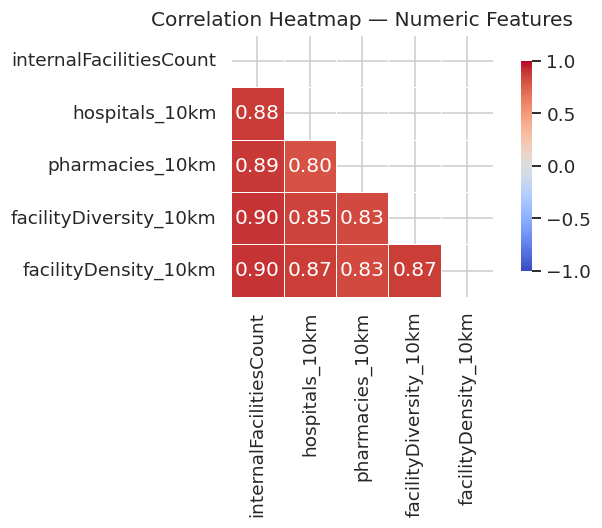

In [9]:
numeric_cols = [
    "internalFacilitiesCount", "hospitals_10km", "pharmacies_10km",
    "facilityDiversity_10km", "facilityDensity_10km",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()


**Observations:**
internalFacilitiesCount` shows strong positive correlation with hospitals_10km,pharmacies_10km, facilityDensity_10km (r ≈ 0.85–0.95).
facilityDiversity_10km, correlates moderately with facility count, suggesting diversity rises alongside infrastructure maturity.
facilityDensity_10km and hospitals_10km` are highly co-linear — centres in denser areas attract more hospitals.


## 3. Feature Selection

All five numeric features are retained because they capture complementary dimensions of research center quality:

| Feature | Rationale |
|---|---|
| `internalFacilitiesCount` | Directly measures own infrastructure capacity |
| `hospitals_10km` | Major external health resource; strongly correlated with quality |
| `pharmacies_10km` | Complementary healthcare metric |
| `facilityDiversity_10km` | Breadth of nearby services — diverse centers serve more needs |
| `facilityDensity_10km` | Overall neighbourhood resource richness |

Geographic columns (`latitude`, `longitude`) and identifiers are **excluded** because quality should be infrastructure-driven, not location-biased.


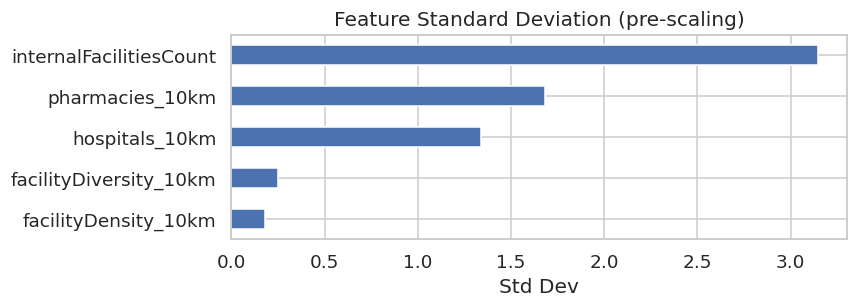

In [10]:
selected_features = [
    "internalFacilitiesCount",
    "hospitals_10km",
    "pharmacies_10km",
    "facilityDiversity_10km",
    "facilityDensity_10km",
]

# Visualise feature variances (before scaling)
fig, ax = plt.subplots(figsize=(8, 3))
df[selected_features].std().sort_values().plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Feature Standard Deviation (pre-scaling)")
ax.set_xlabel("Std Dev")
plt.tight_layout()
plt.savefig("fig_feature_variance.png", bbox_inches="tight")
plt.show()


# 4. K-Means Clustering

# 4.1 Standardise Features
K-Means is distance-based, so features must be on the same scale.


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[selected_features])
print("Scaled feature means (should be ~0):", X_scaled.mean(axis=0).round(4))
print("Scaled feature stds  (should be ~1):", X_scaled.std(axis=0).round(4))


Scaled feature means (should be ~0): [-0. -0. -0.  0.  0.]
Scaled feature stds  (should be ~1): [1. 1. 1. 1. 1.]


### 4.2 Elbow Method — Choosing k

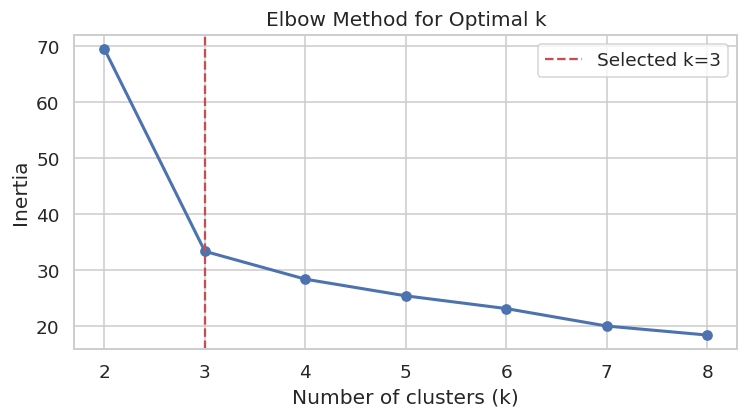

In [12]:
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, inertias, "o-", color="#4C72B0", linewidth=2)
ax.axvline(3, linestyle="--", color="#C44E52", linewidth=1.5, label="Selected k=3")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for Optimal k")
ax.legend()
plt.tight_layout()
plt.savefig("fig_elbow.png", bbox_inches="tight")
plt.show()


# 4.3 Train Final Model (k=3)

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df["cluster"] = kmeans.labels_

sil = silhouette_score(X_scaled, kmeans.labels_)
print(f"Silhouette Score: {sil:.4f}  (closer to 1 = better separation)")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"\nCluster sizes:\n{df['cluster'].value_counts().sort_index()}")


Silhouette Score: 0.5519  (closer to 1 = better separation)
Inertia: 33.40

Cluster sizes:
cluster
0    17
1    17
2    16
Name: count, dtype: int64


# 4.4 Assign Quality Tiers

In [14]:
# Rank clusters by average internalFacilitiesCount (descending)
cluster_rank = (
    df.groupby("cluster")["internalFacilitiesCount"]
    .mean()
    .sort_values(ascending=False)
)
tiers = ["Premium", "Standard", "Basic"]
cluster_to_tier = {int(c): t for c, t in zip(cluster_rank.index, tiers)}
print("Cluster → Tier mapping:", cluster_to_tier)

df["qualityTier"] = df["cluster"].map(cluster_to_tier)
print("\nTier distribution:")
print(df["qualityTier"].value_counts())


Cluster → Tier mapping: {1: 'Premium', 0: 'Standard', 2: 'Basic'}

Tier distribution:
qualityTier
Premium     17
Standard    17
Basic       16
Name: count, dtype: int64


# 5. Model Interpretation

In [15]:
tier_summary = (
    df.groupby("qualityTier")[selected_features]
    .mean()
    .round(3)
    .loc[["Premium", "Standard", "Basic"]]
)
print("Mean feature values per quality tier:")
tier_summary


Mean feature values per quality tier:


,internalFacilitiesCount,hospitals_10km,pharmacies_10km,facilityDiversity_10km,facilityDensity_10km
qualityTier,,,,,
Premium,9.529,3.471,4.118,0.850,0.537
Standard,4.941,1.529,2.059,0.560,0.290
Basic,2.312,0.500,0.438,0.279,0.125


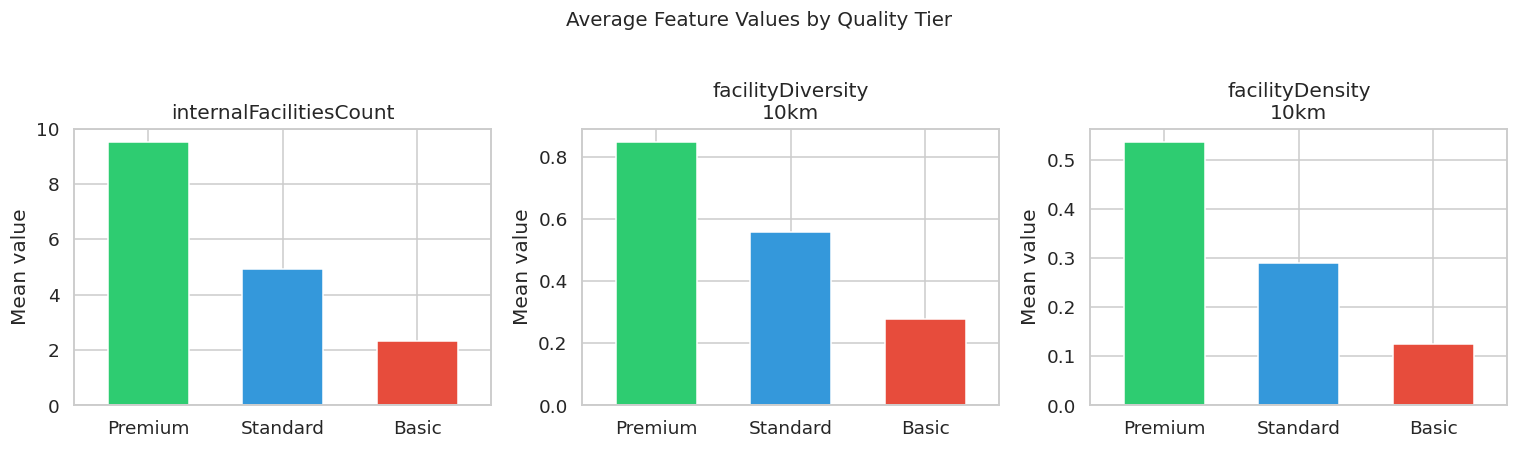

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = {"Premium": "#2ecc71", "Standard": "#3498db", "Basic": "#e74c3c"}

for ax, feat in zip(axes, ["internalFacilitiesCount", "facilityDiversity_10km", "facilityDensity_10km"]):
    means = df.groupby("qualityTier")[feat].mean().loc[["Premium", "Standard", "Basic"]]
    means.plot(kind="bar", ax=ax, color=[palette[t] for t in means.index], edgecolor="white", width=0.6)
    ax.set_title(feat.replace("_", "\n"))
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylabel("Mean value")

plt.suptitle("Average Feature Values by Quality Tier", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig_tier_comparison.png", bbox_inches="tight")
plt.show()


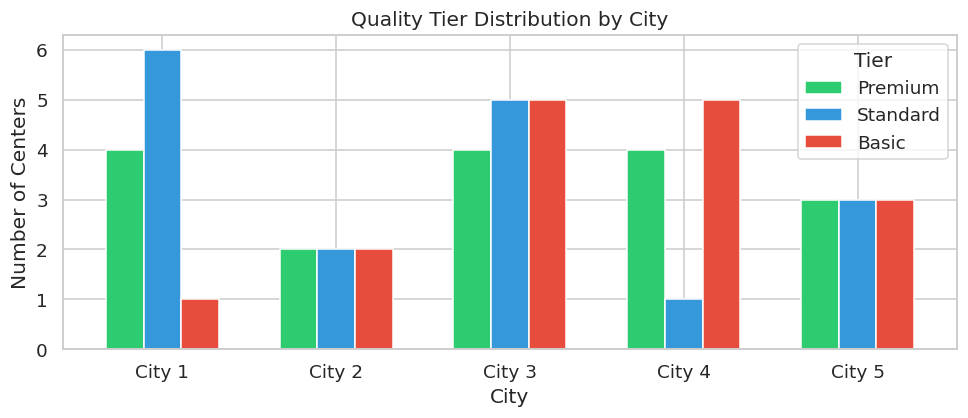

In [17]:
# City distribution of tiers
city_tier = df.groupby(["city", "qualityTier"]).size().unstack(fill_value=0)
city_tier = city_tier.reindex(columns=["Premium", "Standard", "Basic"], fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
city_tier.plot(kind="bar", ax=ax, color=["#2ecc71", "#3498db", "#e74c3c"], edgecolor="white", width=0.65)
ax.set_xlabel("City")
ax.set_ylabel("Number of Centers")
ax.set_title("Quality Tier Distribution by City")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Tier")
plt.tight_layout()
plt.savefig("fig_tier_by_city.png", bbox_inches="tight")
plt.show()


**Key Findings:**
**Premium** centers average ~9.5 internal facilities and ~3.4 hospitals within 10 km — well-resourced on both internal and external dimensions.
**Standard** centers sit in the middle with ~5 facilities and moderate external access; they represent typical, functional research sites.
**Basic** centers average only ~2.3 facilities with minimal hospital/pharmacy access — likely satellite or early-stage sites.
No single city monopolises premium centers, though cities with denser healthcare infrastructure (City 1, City 3, City 4) host slightly more Premium sites.
facilityDiversity_10km` and `facilityDensity_10km` are the most discriminating continuous features — they rise steeply from Basic → Standard → Premium.


# 6. Save Model Artifacts

In [18]:
joblib.dump((kmeans, scaler, selected_features, cluster_to_tier), "cluster_model.pkl")
df.to_csv("research_centers_clustered.csv", index=False)
print("Saved: cluster_model.pkl")
print("Saved: research_centers_clustered.csv")
print("\nSample predictions:")
df[["researchCenterName", "city", "internalFacilitiesCount", "qualityTier"]].head(10)


Saved: cluster_model.pkl
Saved: research_centers_clustered.csv

Sample predictions:


,researchCenterName,city,internalFacilitiesCount,qualityTier
0,Research Center 14,City 4,3,Basic
1,Research Center 40,City 2,2,Basic
2,Research Center 31,City 4,3,Basic
3,Research Center 46,City 5,11,Premium
4,Research Center 18,City 2,10,Premium
5,Research Center 49,City 3,4,Standard
6,Research Center 27,City 3,1,Basic
7,Research Center 26,City 3,8,Premium
8,Research Center 33,City 4,2,Basic
9,Research Center 20,City 5,2,Basic
